In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
print(os.getcwd())

c:\Users\arpit\OneDrive\ドキュメント\ADS Final Year


In [3]:
print(os.listdir())

['Arpita ADS Module1.ipynb', 'Assignment_1B.ipynb', 'Assignment_1_A.ipynb', 'Assignment_1_B.ipynb', 'Assignment_2_A.ipynb', 'Assignment_2_B.ipynb', 'Assignment_3.ipynb', 'copy.txt', 'ev_battery_failure_dataset.csv', 'House Price India.csv', 'sample.txt', 'seg_pred', 'seg_test', 'seg_train', 'test.csv', 'train.csv']


In [4]:
train_dir = "seg_train/seg_train"
test_dir = "seg_test/seg_test"

print("Training Folder :", train_dir)
print("Testing Folder  :", test_dir)

Training Folder : seg_train/seg_train
Testing Folder  : seg_test/seg_test


In [5]:
class_names = sorted(os.listdir(train_dir))

print("Classes are:")

for i, name in enumerate(class_names):
    print(i, ":", name)

Classes are:
0 : buildings
1 : forest
2 : glacier
3 : mountain
4 : sea
5 : street


In [6]:
for name in class_names:

    folder_path = os.path.join(train_dir, name)

    images = [
        file for file in os.listdir(folder_path)
        if file.endswith(".jpg")
    ]

    print(name, ":", len(images), "images")

buildings : 2191 images
forest : 2271 images
glacier : 2404 images
mountain : 2512 images
sea : 2274 images
street : 2382 images


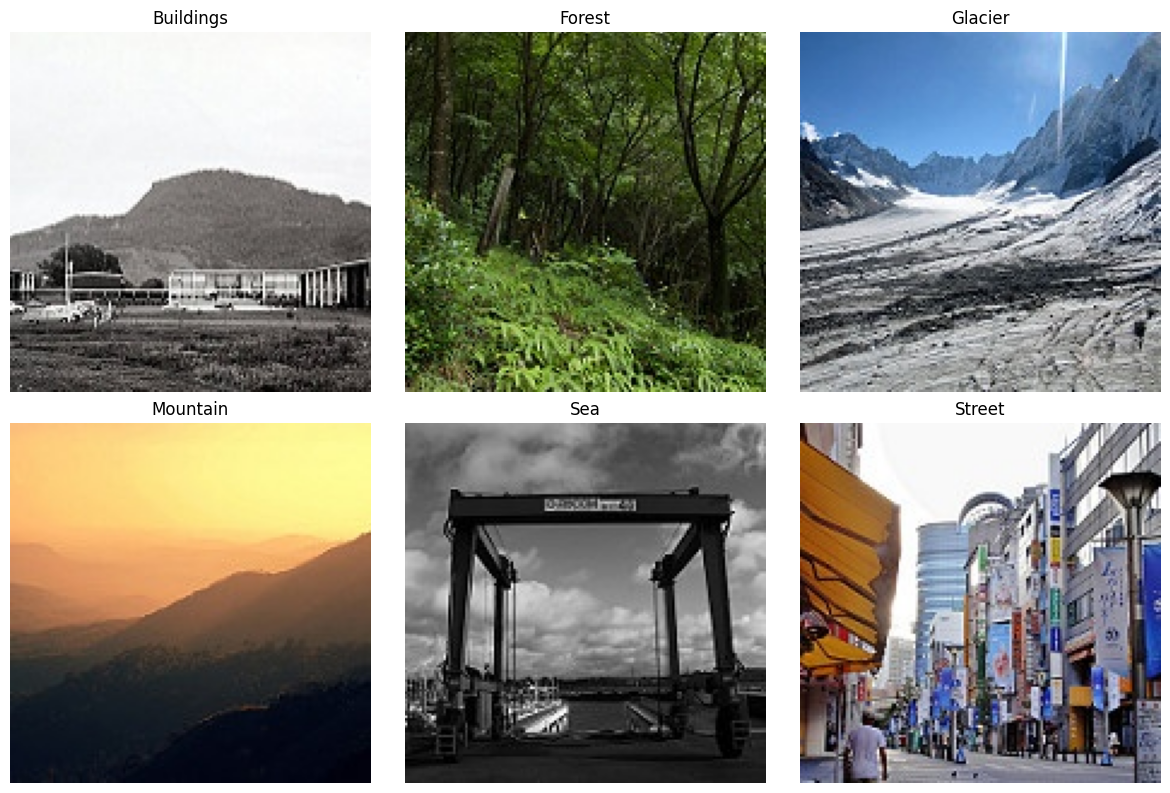

In [7]:
plt.figure(figsize=(12,8))

for i, name in enumerate(class_names):

    folder_path = os.path.join(train_dir, name)

    image_file = os.listdir(folder_path)[0]

    image_path = os.path.join(folder_path, image_file)

    image = plt.imread(image_path)

    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title(name.capitalize())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
IMG_SIZE = (128,128)
BATCH_SIZE = 32
SEED = 42

In [9]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [10]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [11]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


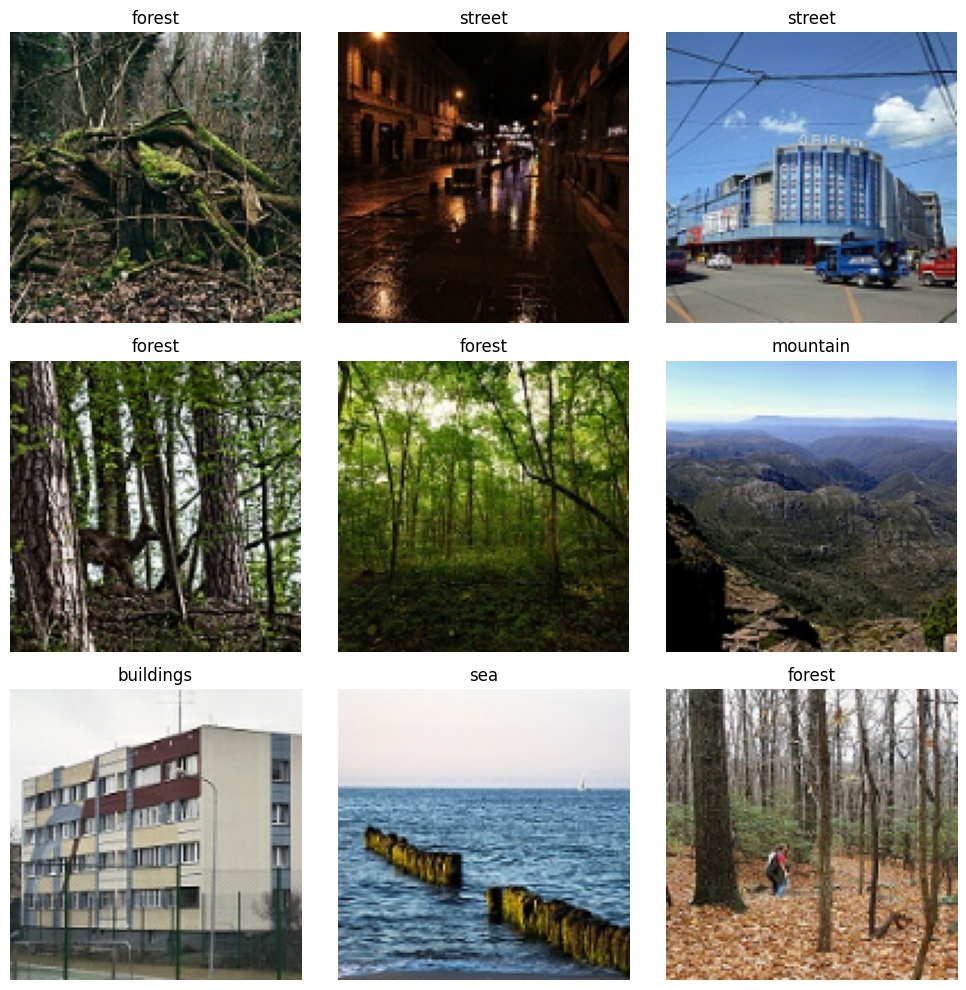

In [12]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)
])

In [14]:
normalization_layer = layers.Rescaling(1./255)

In [15]:
num_classes = 6

model = models.Sequential([

    # Data Augmentation
    data_augmentation,

    # Normalize images
    normalization_layer,

    # First Convolution Layer
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    # Second Convolution Layer
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    # Third Convolution Layer
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    # Flatten Feature Maps
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation="relu"),

    # Dropout
    layers.Dropout(0.3),

    # Output Layer
    layers.Dense(num_classes, activation="softmax")
])

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10


C:\Users\arpit\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 194ms/step - accuracy: 0.5450 - loss: 1.1666 - val_accuracy: 0.6515 - val_loss: 0.9181
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.6374 - loss: 0.9619 - val_accuracy: 0.7128 - val_loss: 0.7607
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.6924 - loss: 0.8372 - val_accuracy: 0.7188 - val_loss: 0.7427
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 89s 253ms/step - accuracy: 0.7206 - loss: 0.7678 - val_accuracy: 0.7270 - val_loss: 0.7016
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 104s 296ms/step - accuracy: 0.7390 - loss: 0.7135 - val_accuracy: 0.7327 - val_loss: 0.7170
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 104s 295ms/step - accuracy: 0.7596 - loss: 0.6718 - val_accuracy: 0.7855 - val_loss: 0.6084
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 105s 299ms/step - accuracy: 0.7729 - loss: 0.6376 - val_accuracy: 0.7751 - val_loss: 0.6096
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 109s 310ms/step - accuracy: 0.7763 - loss: 0.6234 -

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

NameError: name 'y_true' is not defined

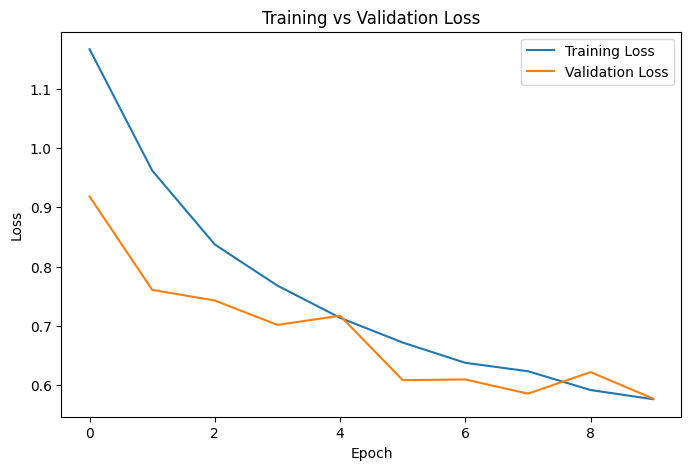

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [21]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

print("Accuracy Percentage:", test_accuracy * 100)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8010 - loss: 0.5859
Test Loss: 0.5858994722366333
Test Accuracy: 0.8009999990463257
Accuracy Percentage: 80.09999990463257


In [22]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [23]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   buildings       0.80      0.69      0.74       437
      forest       0.92      0.97      0.94       474
     glacier       0.83      0.69      0.75       553
    mountain       0.79      0.70      0.74       525
         sea       0.71      0.87      0.78       510
      street       0.79      0.90      0.84       501

    accuracy                           0.80      3000
   macro avg       0.81      0.80      0.80      3000
weighted avg       0.80      0.80      0.80      3000



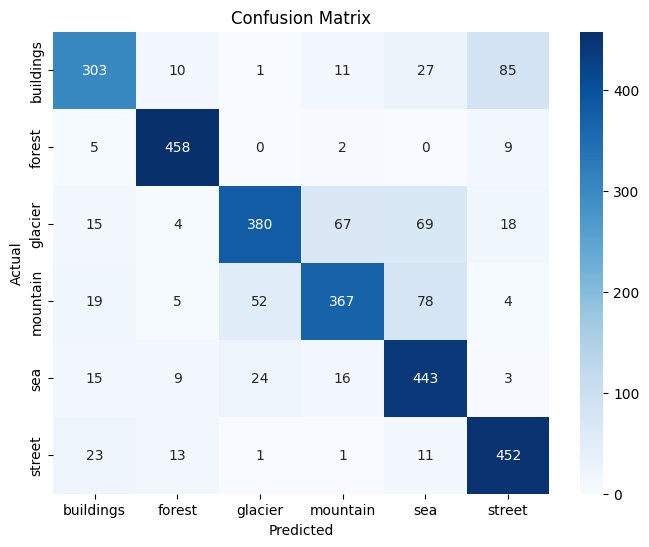

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [25]:
model.save("intel_cnn_model.keras")

print("Model saved successfully")

Model saved successfully


In [26]:
pred_dir = "seg_pred/seg_pred"

print(os.listdir(pred_dir)[:10])

['10004.jpg', '10005.jpg', '10012.jpg', '10013.jpg', '10017.jpg', '10021.jpg', '1003.jpg', '10034.jpg', '10038.jpg', '10040.jpg']


In [27]:
pred_dir = "seg_pred"

In [28]:
image_name = os.listdir(pred_dir)[0]

image_path = os.path.join(pred_dir, image_name)

print(image_path)

seg_pred\seg_pred


In [31]:
import os

pred_dir = "seg_pred/seg_pred"

print(os.listdir(pred_dir)[:20])

['10004.jpg', '10005.jpg', '10012.jpg', '10013.jpg', '10017.jpg', '10021.jpg', '1003.jpg', '10034.jpg', '10038.jpg', '10040.jpg', '10043.jpg', '10045.jpg', '10047.jpg', '10048.jpg', '10052.jpg', '10054.jpg', '10059.jpg', '10060.jpg', '10066.jpg', '10069.jpg']


In [32]:
image_files = [
    file for file in os.listdir(pred_dir)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of prediction images:", len(image_files))
print("First few images:", image_files[:5])

Number of prediction images: 7301
First few images: ['10004.jpg', '10005.jpg', '10012.jpg', '10013.jpg', '10017.jpg']


In [33]:
image_name = image_files[0]

image_path = os.path.join(pred_dir, image_name)

print("Selected image:", image_path)

Selected image: seg_pred/seg_pred\10004.jpg


In [34]:
from tensorflow.keras.utils import load_img, img_to_array

image = load_img(
    image_path,
    target_size=(128, 128)
)

print("Image loaded successfully!")

Image loaded successfully!


In [35]:
image_array = img_to_array(image)

image_array = np.expand_dims(
    image_array,
    axis=0
)

prediction = model.predict(image_array)

predicted_index = np.argmax(prediction)

predicted_class = class_names[predicted_index]

confidence = np.max(prediction) * 100

print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Class: street
Confidence: 77.42%


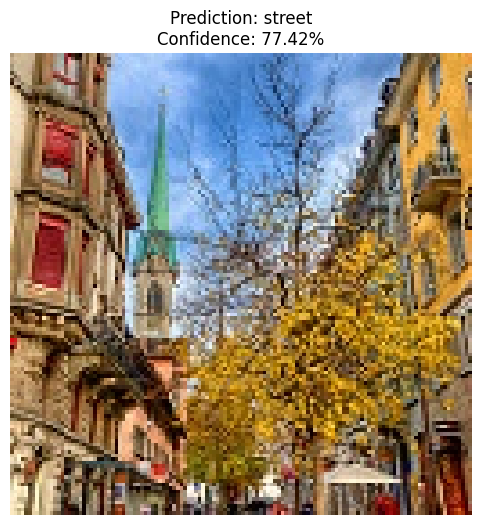

In [36]:
plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

In [37]:
def predict_image(image_path):

    image = load_img(
        image_path,
        target_size=(128, 128)
    )

    image_array = img_to_array(image)

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    prediction = model.predict(
        image_array,
        verbose=0
    )

    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]

    confidence = np.max(prediction) * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(image)

    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")
    plt.show()

    print("Predicted Class:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

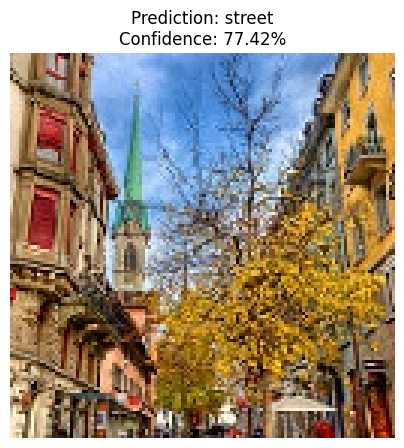

Predicted Class: street
Confidence: 77.42%


In [38]:
predict_image(image_path)